# Forecasting notebook overview

**Operational forecast**

NOTE: this version of the forecasting notebook preserves code that is edited out of the final forecasting notebook (5_ch4_forecasting), including:
- forecasting future timepoints using inervals calibrated on the train data only (as apposed to the full series)
- forecasting future timepoints using intervals calibrated on the full series using code that is specific to the UCM model and localized to this notebook (as apposed to the more streamlined and generalizable code stored in the forecasting.py file and more cleanly called within this notebook.  This latter code is in the second operational forecast section.).

This notebook produces an operational forecast using the top model, selected and validated in the modeling notebook (4_ch4_modeling) against a held-out test set consisting of the the most recent two years of data.  (CRPS 8.55 vs. seasonal naive 11.78; near-nominal coverage at 50/80/95% across all horizons — see Section 6 in that notebook for full evidence). Here, we refit the same model specification on all available data to produce the most current possible forecast, following standard operational practice.

Primary forecasting model:  UCM
- The UCM was selected as the primary forecasting model based on its out-of-sample probabilistic forecast performance and interval calibration.
- it has the lowest CRPS from both single-origin and rolling-origin forecasts on the test data across all horizons.
- Its target-year CRPS was remarkably similar for 2023 and 2024 despite the very different horizon composition.

**The top model architecture**:

Component | Description
----------|------------
Mean model | UCM (random walk with drift + K=4 harmonics + AR(1), (stoch_freq_seasonal=True))
Native uncertainty | State-space forecast standard error (se_mean)
Variance calibration | se_mean × horizon-dependent scale factor
Interval calibration | Gaussian ACI, gamma=0.02

**Secondary forecast model**:

Component | Description
----------|------------
Mean model | SARIMA(1,1,1)(1,0,1,52), trend = c
Native uncertainty | Model-based standard error
Variance calibration | Forecast standard error × horizon-dependent scale factor
Interval calibration | Gaussian ACI, gamma=0.02

**Conceptual map of model(s)**

RAW DATA
    ↓
GasPreprocessor (outlier removal, interpolation)
    ↓
MEAN MODEL (UCM, SARIMA, etc.)
    → Produces: point forecast (mu) + native uncertainty (sigma_native)
    → Evaluated by: RMSE / MAE at horizon
    ↓
VARIANCE SCALING
    → Corrects sigma_native to match actual error magnitude
    → Produces: sigma_calibrated
    → Evaluated by: CRPS
    ↓
ACI (Adaptive Conformal Inference)
    → Adjusts interval width to maintain 95% coverage over time
    → Produces: lower_aci, upper_aci
    → Evaluated by: coverage rate
    ↓
FINAL OUTPUT
    → Point forecast: mu
    → Calibrated intervals: [lower_aci, upper_aci]

# Libraries

In [78]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import os
from pathlib import Path
import pickle
import json
from statsmodels.stats.diagnostic import acorr_ljungbox

from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.statespace.sarimax import SARIMAX

import sys
sys.path.append('../')

from src import forecasting as fc
from src import model_evaluation as me
from src import posthoc_calibration as pc

print('forecasting imported successfully!')
print('model_evaluation imported successfully!')
print('posthoc_calibration imported successfully!')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
forecasting imported successfully!
model_evaluation imported successfully!
posthoc_calibration imported successfully!


# Load data

## file directory info

**Define relative paths from the root of this project**
- processed_data_dir = os.path.join("data", "processed")
- forecasting_data_dir = os.path.join("data", "forecasting_data")

greenhouse-gas-forecasting/
├── data/
│   ├── processed/
│   │   ├── CH4_train_preprocessed.pkl      # Preprocessed training dataset
│   │   └── CH4_test_preprocessed.pkl       # Preprocessed testing dataset
│   └── forecasting_data/
│       ├── fitted_models/                  # Stored model specs and trained architectures
│       └── calibration/                    # Model calibration and validation files
└── notebooks/
    └── [5_ch4_forecasting].ipynb          # This notebook

## train and test sets

In [37]:
# load the pickle files

output_dir = Path("../data/processed")

train_preprocessed_df = pd.read_pickle(output_dir / "CH4_train_preprocessed.pkl")
test_preprocessed_df = pd.read_pickle(output_dir / "CH4_test_preprocessed.pkl")

In [38]:
train_preprocessed_df.head()

,CH4_preprocessed,value_unc,qcflag
1991-01-06,1719.845,2.71,...
1991-01-13,1736.940,2.71,...
1991-01-20,1728.335,2.71,...
1991-01-27,1716.080,2.71,...
1991-02-03,1727.430,2.71,...


In [39]:
train_preprocessed_df.describe()

,CH4_preprocessed,value_unc
count,1669.000000,1639.000000
mean,1810.978201,1.539019
std,51.454037,0.711564
min,1709.020000,0.575000
25%,1773.175000,0.910000
50%,1799.530000,1.400000
75%,1845.730000,2.050000
max,1970.875000,2.710000


In [40]:
print("train_preprocessed min and max date index:")
print(f"min: {train_preprocessed_df.index.min().date()}")
print(f"max: {train_preprocessed_df.index.max().date()}")

train_preprocessed min and max date index:
min: 1991-01-06
max: 2022-12-25


In [41]:
test_preprocessed_df.head()

,CH4_preprocessed,value_unc,qcflag
2023-01-01,1951.4675,0.575,...
2023-01-08,1931.1000,0.575,...
2023-01-15,1933.3625,0.575,...
2023-01-22,1929.8025,0.575,...
2023-01-29,1941.1150,0.575,...


In [42]:
test_preprocessed_df.describe()

,CH4_preprocessed,value_unc
count,105.000000,8.800000e+01
mean,1940.870211,5.750000e-01
std,18.446392,1.116585e-16
min,1906.600000,5.750000e-01
25%,1929.217500,5.750000e-01
50%,1940.986667,5.750000e-01
75%,1952.870000,5.750000e-01
max,1989.377500,5.750000e-01


In [43]:
print("test_preprocessed min and max date index:")
print(f"min: {test_preprocessed_df.index.min().date()}")
print(f"max: {test_preprocessed_df.index.max().date()}")

test_preprocessed min and max date index:
min: 2023-01-01
max: 2024-12-29


In [44]:
# confirm that the gap between train and test sets is one week

print(f"last train_preprocessed_df index date: {train_preprocessed_df.index[-1].date()}")
print(f"first test_preprocessed_df index date: {test_preprocessed_df.index[0].date()}")

train_test_gap = test_preprocessed_df.index[0] - train_preprocessed_df.index[-1]
print(f"gap between train and test sets = {train_test_gap}")

last train_preprocessed_df index date: 2022-12-25
first test_preprocessed_df index date: 2023-01-01
gap between train and test sets = 7 days 00:00:00


In [45]:
# extract only the CH4 values column from each dataframe

train_preprocessed = train_preprocessed_df['CH4_preprocessed']
test_preprocessed = test_preprocessed_df['CH4_preprocessed']

In [46]:
print(train_preprocessed.describe)

<bound method NDFrame.describe of 1991-01-06    1719.8450
1991-01-13    1736.9400
1991-01-20    1728.3350
1991-01-27    1716.0800
1991-02-03    1727.4300
                ...    
2022-11-27    1958.5475
2022-12-04    1956.4500
2022-12-11    1954.3525
2022-12-18    1952.2550
2022-12-25    1950.1575
Freq: W-SUN, Name: CH4_preprocessed, Length: 1669, dtype: float64>


In [47]:
print(test_preprocessed.describe)

<bound method NDFrame.describe of 2023-01-01    1951.46750
2023-01-08    1931.10000
2023-01-15    1933.36250
2023-01-22    1929.80250
2023-01-29    1941.11500
                 ...    
2024-12-01    1970.82500
2024-12-08    1959.45000
2024-12-15    1941.22625
2024-12-22    1923.00250
2024-12-29    1952.38000
Freq: W-SUN, Name: CH4_preprocessed, Length: 105, dtype: float64>


## model specs, fitted models, and calibration files

In [48]:
# print the path to where the notebook is running
print(Path.cwd())

C:\Users\aplor\Documents\GitHub\greenhouse-gas-forecasting\notebooks


In [49]:
output_dir = Path("../data/forecasting_data")

models_dir = output_dir / "fitted_models"
calibration_dir = output_dir / "calibration"

In [50]:
print(output_dir.resolve())
print(output_dir.exists())

C:\Users\aplor\Documents\GitHub\greenhouse-gas-forecasting\data\forecasting_data
True


**Note about path**
Both data and notebook folders are in the greenhouse-gas-forecasting folder.  

In [51]:
# load the model specs
with open(output_dir / "model_specs.json") as f:
    model_specs = json.load(f)

print("loaded model specs for UCM and SARIMA models")
print(f"\nUCM model specs: {model_specs['UCM']}")
print(f"\nSARIMA model specs: {model_specs['SARIMA']}")

loaded model specs for UCM and SARIMA models

UCM model specs: {'level': 'random walk with drift', 'freq_seasonal': [{'period': 52.18, 'harmonics': 4}], 'stochastic_freq_seasonal': [True], 'autoregressive': 1}

SARIMA model specs: {'order': [1, 1, 1], 'seasonal_order': [1, 0, 1, 52], 'trend': 'c'}


In [52]:
# load fitted models
# I will load only SARIMA and UCM models since these are the top models based on skill and test forecast CRPS 
fitted_models = {}

for name in ["SARIMA", "UCM"]:
    file = models_dir / f"{name}_fit.pkl"
    with open(file, "rb") as f:
        fitted_models[name] = pickle.load(f)

print(f"loaded {len(fitted_models)} fitted models:")
print(list(fitted_models.keys()))

loaded 2 fitted models:
['SARIMA', 'UCM']


In [53]:
# load calibration data for the top models 
# I will load the calibration data for only SARIMA and UCM models since these are the top models based on skill and test forecast CRPS 
calibration = {}

for name in ["SARIMA", "UCM"]:
    file = calibration_dir / f"{name}_calibration.pkl"
    with open(file, "rb") as f:
        calibration[name] = pickle.load(f)

print(f"loaded {len(calibration)} calibration files:")
print(list(calibration.keys()))

loaded 2 calibration files:
['SARIMA', 'UCM']


# Forecast vs test set

**Forecast against test set - pipeline**

The following steps were performed in the 4_ch4_modeling notebook and the resuls/data have been loaded above:
1. Fit the model on full training data 
2. Run rolling_crps on training data to get the results data frame 
3. Trim results to common_start_idx = 492 (This was set in the 4_ch4_modeling to accommodate breakpoints, which are not used here)
4. Apply variance scaling to trimmed results
5. Apply ACI to scaled results, extract final alpha_t <br><br>The following steps are performed in this notebook:
6. Forecast on test set using the fitted model
7. Apply variance scaling and ACI to test forecasts

## single-origin forecast for top models

In [54]:
# exog_test_map is a dictionary for model:exogenous variable (e.g. exog_bp_test).
# the top models (SARIMA and UCM) do not use exogenous variables, but the code remains for possible future use.
exog_test_map = {
    'UCM'   : None,
    'SARIMA': None
}

all_test_forecasts_95 = {}
all_test_forecasts_80 = {}
all_test_forecasts_50 = {}

for name in fitted_models:
    cal    = calibration[name]        # from run_calibration_pipeline()
    result = fitted_models[name]
    exog_t = exog_test_map[name]

    all_test_forecasts_95[name] = fc.single_origin_forecast(
        fitted_result=result,
        test_series=test_preprocessed,
        exog_test=exog_t,
        scale_factors=cal['scale_factors'],
        final_alpha=cal['calibrations'][0.95]['final_alpha'],
        target_coverage=0.95,
    )

    all_test_forecasts_80[name] = fc.single_origin_forecast(
        fitted_result=result,
        test_series=test_preprocessed,
        exog_test=exog_t,
        scale_factors=cal['scale_factors'],
        final_alpha=cal['calibrations'][0.80]['final_alpha'],
        target_coverage=0.80
    )

    all_test_forecasts_50[name] = fc.single_origin_forecast(
        fitted_result=result,
        test_series=test_preprocessed,
        exog_test=exog_t,
        scale_factors=cal['scale_factors'],
        final_alpha=cal['calibrations'][0.50]['final_alpha'],
        target_coverage=0.50
    )

    print(f"{name}: 95%, 80%, and 50% single-origin forecasts complete")

SARIMA: 95%, 80%, and 50% single-origin forecasts complete
UCM: 95%, 80%, and 50% single-origin forecasts complete


In [55]:
# Build naive forecast dictionary matching the structure of all_test_forecasts_{cal}
# CRPS and y_pred are identical across coverage levels (naive uses one fixed sigma)
# only the interval width / covered_aci flag changes per level.

full_series = pd.concat([train_preprocessed, test_preprocessed])

# compute sigma for the naive forecast
train_naive_errors = train_preprocessed.values[52:] - train_preprocessed.values[:-52]
naive_sigma = np.std(train_naive_errors, ddof=1)

# helper function to compute CRPS for a normaly distributed probabilistic forecast
def crps_normal(y, mu, sigma):
    z = (y - mu) / sigma
    phi = stats.norm.pdf(z)
    Phi = stats.norm.cdf(z)
    return sigma * (z * (2 * Phi - 1) + 2 * phi - 1 / np.sqrt(np.pi))


naive_base = pd.DataFrame({
    'date'  : test_preprocessed.index,
    'y_true': test_preprocessed.values
})

naive_base['y_pred'] = full_series.reindex(
    naive_base['date'] - pd.Timedelta(weeks=52)
).values
naive_base['error'] = naive_base['y_pred'] - naive_base['y_true']
naive_base['abs_error'] = naive_base['error'].abs()
naive_base['crps'] = crps_normal(
    naive_base['y_true'].values,
    naive_base['y_pred'].values,
    naive_sigma  # from training residuals
)

all_test_forecasts_naive = {}

for cal, z in [(95, 1.960), (80, 1.2816), (50, 0.6745)]:
    df = naive_base.copy()
    df['lower_aci'] = df['y_pred'] - z * naive_sigma
    df['upper_aci'] = df['y_pred'] + z * naive_sigma
    df['covered_aci'] = (
        (df['y_true'] >= df['lower_aci']) & (df['y_true'] <= df['upper_aci'])
    ).astype(float)
    all_test_forecasts_naive[cal] = df

# merge into coverage leve-specific forecast dictionararies 
all_test_forecasts_95['Seasonal Naive'] = all_test_forecasts_naive[95]
all_test_forecasts_80['Seasonal Naive'] = all_test_forecasts_naive[80]
all_test_forecasts_50['Seasonal Naive'] = all_test_forecasts_naive[50]

In [56]:
# summary comparison table of single-origin forecast results

single_origin_fc_summary = {
    95: {'forecasts':all_test_forecasts_95, 'records':[]},
    80: {'forecasts':all_test_forecasts_80, 'records':[]},
    50: {'forecasts':all_test_forecasts_50, 'records':[]}
}

single_origin_fc_summary_dfs = {}

for cal in single_origin_fc_summary.keys():
    config = single_origin_fc_summary[cal]

    if not config['forecasts']:
        print(f"Warning: 'all_test_forecasts_{cal}' is empty! Skipping this level.")
        continue

    for name, fc_df in config['forecasts'].items():
        # Full test period
        config['records'].append({
            'model'           : name,
            'period'          : 'Full Test',
            'mean_crps'       : fc_df['crps'].mean(),
            'mae'             : fc_df['abs_error'].mean(),
            f'coverage_{cal}%': fc_df['covered_aci'].mean(),
            'n_weeks'         : len(fc_df),
        })
        
        # Split by year
        for year in [2023, 2024]:
            yr_df = fc_df[fc_df['date'].dt.year == year]
            if len(yr_df) > 0:
                config['records'].append({
                    'model'           : name,
                    'period'          : str(year),
                    'mean_crps'       : yr_df['crps'].mean(),
                    'mae'             : yr_df['abs_error'].mean(),
                    f'coverage_{cal}%': yr_df['covered_aci'].mean(),
                    'n_weeks'         : len(yr_df),
                })

    # build the datafrome for the calibration level of the current loop
    single_origin_fc_summary_dfs[cal] = pd.DataFrame(config['records'])

# Print the mean CRPS summary table
print(f"\n--- Mean CRPS From Single-Origin Forecast ---")
pivot_crps = single_origin_fc_summary_dfs[cal].pivot(
    index='model',
    columns='period',
    values='mean_crps'
).reindex(
    index=['UCM','SARIMA','Seasonal Naive'],
    columns=['2023','2024','Full Test']).round(3)
print(pivot_crps)
    
# Print the coverage summary table
for cal in single_origin_fc_summary.keys():
    print(f"\n--- Mean Nominal {cal}% Coverage From Single-Origin Forecast ---")
    pivot_coverage = single_origin_fc_summary_dfs[cal].pivot(
        index='model',
        columns='period',
        values=f'coverage_{cal}%'
    ).reindex(
        index=['UCM','SARIMA','Seasonal Naive'],
        columns=['2023','2024','Full Test']).round(3)
    print(pivot_coverage)

# the three standalone dataframes are now fully accessible here:
so_fc_summary_df_95 = single_origin_fc_summary_dfs[95]
so_fc_summary_df_80 = single_origin_fc_summary_dfs[80]
so_fc_summary_df_50 = single_origin_fc_summary_dfs[50]


--- Mean CRPS From Single-Origin Forecast ---
period            2023    2024  Full Test
model                                    
UCM              8.079   9.036      8.553
SARIMA           8.511  10.028      9.262
Seasonal Naive  11.166  12.407     11.780

--- Mean Nominal 95% Coverage From Single-Origin Forecast ---
period           2023   2024  Full Test
model                                  
UCM             0.981  0.981      0.981
SARIMA          0.943  0.981      0.962
Seasonal Naive  0.925  0.923      0.924

--- Mean Nominal 80% Coverage From Single-Origin Forecast ---
period           2023   2024  Full Test
model                                  
UCM             0.868  0.885      0.876
SARIMA          0.849  0.827      0.838
Seasonal Naive  0.736  0.731      0.733

--- Mean Nominal 50% Coverage From Single-Origin Forecast ---
period           2023   2024  Full Test
model                                  
UCM             0.623  0.808      0.714
SARIMA          0.623  0.731      

## single-origin forecast comparison plots

In [57]:
test_preprocessed.index.year.unique()

Index([2023, 2024], dtype='int32')

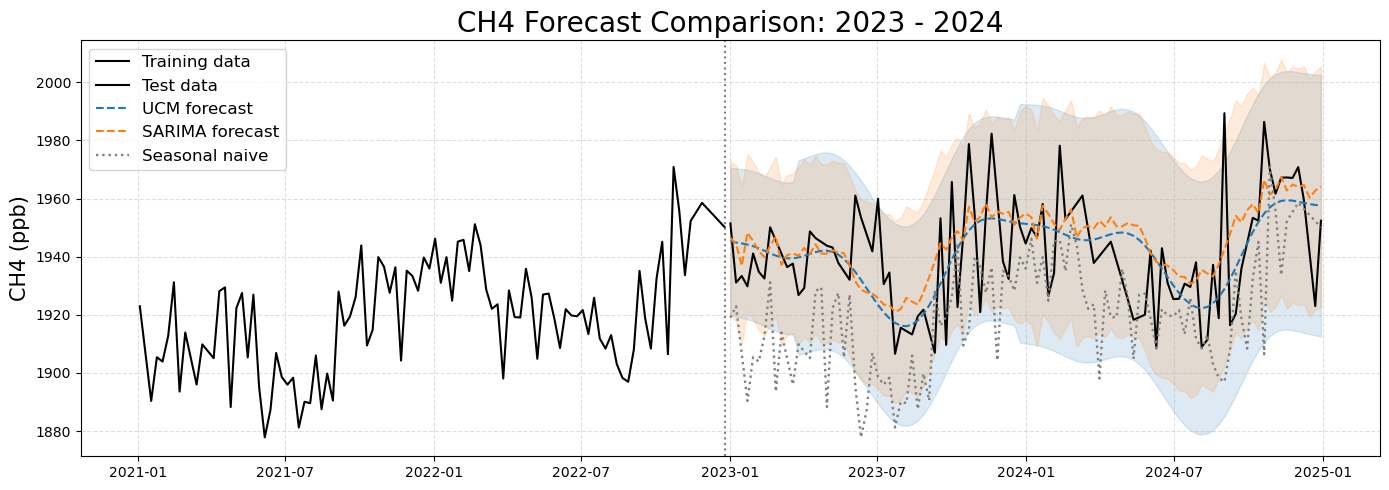

In [58]:
test_years = f'{test_preprocessed.index.year.unique()[0]} - {test_preprocessed.index.year.unique()[1]}'

fig, ax = plt.subplots(figsize=(14, 5))

#train_tail = train_preprocessed.loc['2021':]
train_tail = train_preprocessed.iloc[-104:]
ax.plot(train_tail.index, train_tail.values, color='black', linewidth=1.5,
        alpha=1.0, label='Training data')
ax.plot(test_preprocessed.index, test_preprocessed.values, color='black',
        linewidth=1.5, label='Test data')

for name in ['UCM', 'SARIMA']:
    forecast = all_test_forecasts_95[name]
    line, = ax.plot(forecast['date'], forecast['y_pred'], linewidth=1.5, linestyle='--', label=f'{name} forecast')
    ax.fill_between(forecast['date'], forecast['lower_aci'], forecast['upper_aci'], color=line.get_color(), alpha=0.15)

# Seasonal naive reference (52-week lag of training)
naive_vals = train_preprocessed.reindex(
    test_preprocessed.index - pd.Timedelta(weeks=105)
).values
ax.plot(test_preprocessed.index, naive_vals, color='gray', linewidth=1.7, linestyle=':', label='Seasonal naive')

ax.axvline(train_preprocessed.index[-1], color='gray', linestyle=':', linewidth=1.5)
#ax.set_title(f'CH4 Forecast Comparison: {test_years}', fontsize=20)
ax.set_title(f'CH4 Forecast Comparison: {test_years}', fontsize=20)
ax.set_ylabel('CH4 (ppb)', fontsize=15)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Forecast over test years summary**

On the held-out 2023–2024 test period, both UCM and SARIMA substantially outperform the seasonal naive benchmark (11.78 ppb), confirming genuine forecasting skill beyond simple year-over-year persistence. UCM achieves the lowest mean CRPS (8.55 ppb, vs. SARIMA's 9.26 ppb) across the full test period, with both models showing modestly higher error in 2024 than 2023, which is expected for longer forecast horizons. Empirical coverage for both models are above target at the nominal 95% level (0.981 for UCM and 0.962 for SARIMA), indicating the calibrated prediction intervals are conservative (wider than strictly necessary) rather than overconfident. This may be attributable to the ACI calibration inheriting wide interval widths learned during the volatile 2020–2022 training period.

# Forecast - train series calibration

- the following forecast is based on the top model fit and calibrated on the training data only according to the model training and evaluation performed in the 4_ch4_modeling notebook.
- this forecast relies primarily on imported data from the 4_ch4_modeling notebook.
- the section that follows is an operational forecast involving interval calibration of the full series.

The future forecast utlizing train series calibration data — order of operations:

1. Refit the model on the combined train+test data (all observed data). This is new, since the current fitted_models were fit on train only.
2. Reuse the existing calibration['UCM'] (scale_factors, final_alpha), which were already computed and saved from 4_ch4_modeling notebook.
3. Generate the forecast for the desired future horizon using the refit model (get_forecast(steps=52) or however far ahead is desired).
4. Apply variance scaling and ACI to that forecast using the existing calibration parameters from step 2, which is exactly the same single_origin_forecast-style logic already built and validated on the test set.

In [59]:
# refit the model on the combined train+test data 
full_series = pd.concat([train_preprocessed, test_preprocessed])

# set the number of time steps to forecast (n_forecast; 1-52) and calibration interval (target_coverage; 0.50, 0.80, or 0.95)
n_forecast = 52
target_coverage = 0.95

# for warm start 
warm_start_params = fitted_models['UCM'].params

full_model = UnobservedComponents(full_series, **model_specs['UCM'])
full_model_result = full_model.fit(
    method='lbfgs', 
    start_params=warm_start_params,
    maxiter=2000, 
    disp=False
)

# reuse existing calibration (already loaded at the top of this notebook, from "ch4_modeling" notebook)
cal = calibration['UCM']
final_alpha = cal['calibrations'][target_coverage]['final_alpha']

# generate raw forecast
fc_full = full_model_result.get_forecast(steps=n_forecast)
mu_full = fc_full.predicted_mean
sigma_full = fc_full.se_mean

# apply variance scaling + adaptive conformal inference (ACI)
sf_horizons = sorted(cal['scale_factors'].index.tolist())
alpha_horizons = sorted(final_alpha.index.tolist())

last_date = full_series.index[-1]

rows = []
for i in range(n_forecast):
    h = i + 1
    h_sf = max([x for x in sf_horizons if x <= h], default=sf_horizons[0])
    h_alpha = max([x for x in alpha_horizons if x <= h], default=alpha_horizons[0])

    sigma_cal = sigma_full.iloc[i] * cal['scale_factors'].loc[h_sf]
    z_t = stats.norm.ppf(1 - final_alpha.loc[h_alpha] / 2)

    forecast_date = last_date + pd.Timedelta(weeks=h)

    rows.append({
        'horizon': h,
        'date': forecast_date,
        'y_pred': mu_full.iloc[i],
        'sigma': sigma_full.iloc[i],
        'sigma_calibrated': sigma_cal,
        'lower': mu_full.iloc[i] - z_t * sigma_cal,
        'upper': mu_full.iloc[i] + z_t * sigma_cal
    })

forecast_df = pd.DataFrame(rows)
print(forecast_df.head())
print(f"\nForecast range: {forecast_df['date'].min().date()} " 
      f"to {forecast_df['date'].max().date()}")

   horizon       date       y_pred      sigma  sigma_calibrated        lower  \
0        1 2025-01-05  1954.379621  12.909171         13.319752  1928.820666   
1        2 2025-01-12  1954.430102  13.084840         13.501009  1928.523338   
2        3 2025-01-19  1954.391574  13.133687         13.551408  1928.388098   
3        4 2025-01-26  1954.357682  13.171748         13.590680  1928.278849   
4        5 2025-02-02  1954.272521  13.205090         13.625083  1928.127672   

         upper  
0  1979.938577  
1  1980.336866  
2  1980.395049  
3  1980.436515  
4  1980.417369  

Forecast range: 2025-01-05 to 2025-12-28


In [60]:
# sanity check for refit

prior_good_params = fitted_models['UCM'].params

ucm_check_refit = fc.sanity_check_refit(
    full_model_result,
    full_series,
    'UCM',
    prior_good_params=prior_good_params
)

ucm_check_refit


Sanity check: UCM refit on 1991-01-06 to 2024-12-29
✓ No issues detected — refit looks consistent with prior years


True

## plot - future forecast

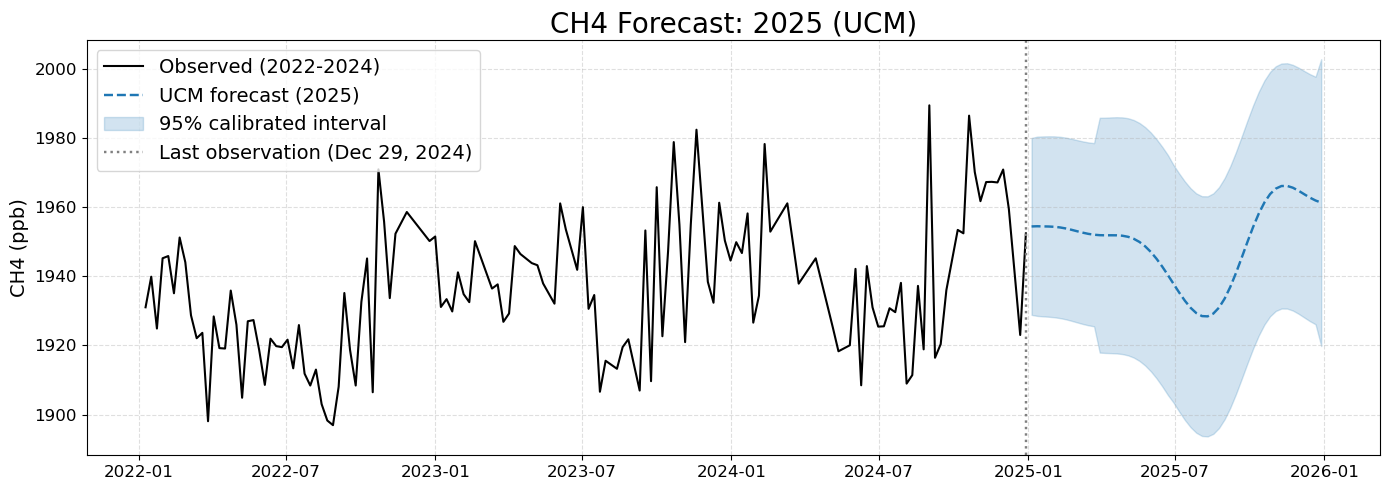

In [61]:
# set model type and calibration level
model = 'UCM'
calibration_lvl = 95  # choose 50, 80, or 95

# Recent observed history for context
recent_tail = full_series.iloc[-156:]  # last three years
start_year = recent_tail.index[0].year
end_year = recent_tail.index[-1].year
forecast_year = (recent_tail.index[-1] + pd.DateOffset(weeks=4)).year

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(recent_tail.index, recent_tail.values, color='black',
        linewidth=1.5, label=f'Observed ({start_year}-{end_year})')

# Forecast
line, = ax.plot(forecast_df['date'], forecast_df['y_pred'],
                linewidth=1.75, linestyle='--', label=f'{model} forecast ({forecast_year})')
ax.fill_between(forecast_df['date'], forecast_df['lower'],
                forecast_df['upper'], color=line.get_color(), alpha=0.2,
                label=f'{calibration_lvl}% calibrated interval')

ax.axvline(full_series.index[-1], color='gray', linestyle=':', linewidth=1.75,
           label=f'Last observation ({recent_tail.index[-1].strftime('%b %d, %Y')})')

ax.set_title(f'CH4 Forecast: {forecast_year} ({model})', fontsize=20)
ax.set_ylabel('CH4 (ppb)', fontsize=14)

ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=14, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## forecast values - future forecast

In [62]:
# print the future forecast values at 1, 13, 26, and 52 weeks ahead

future_forecast_values = forecast_df[forecast_df['horizon'].isin([1, 13, 26, 52])].copy()

# operational_forecast_values['label'] = operational_forecast_values['horizon'].map({
#     1: '1 week ahead',
#     13: '~1 quarter ahead',
#     26: '~6 months ahead',
#     52: '~1 year ahead'
# })

print('Future Forecast Values at Specific Horizons (weeks ahead):\n')
columns_to_print = ['horizon', 'date', 'y_pred', 'lower', 'upper']
print(future_forecast_values[columns_to_print].round(2).to_string(index=False))

Future Forecast Values at Specific Horizons (weeks ahead):

 horizon       date  y_pred   lower   upper
       1 2025-01-05 1954.38 1928.82 1979.94
      13 2025-03-30 1951.85 1917.92 1985.79
      26 2025-06-29 1937.78 1903.44 1972.12
      52 2025-12-28 1961.26 1919.81 2002.71


# Operational Forecast 

- calibration on full series, as apposed to the train series only as in the forecast above
- This forecast uses local code blocks and is redundant with the subsequent operational forecast that calls functions from saved .py files from the SRC folder in the Github repository.  It is being left here as an early version of the final notebook for future reference.

  
- Production-style recalibration incorporating test set data
- NOTES:
  - this is a distinct, forward-looking recalibration step, separate from and performed after the primary held-out validation reported above.
  - some of the following code is redundant with the previous forecast that utilized calibration data from the train data only.  This redundancy is for the contigency of running only one of the forecasts.  

Justification: First, the intention is for this code to be useful and productive in subsequent years, following future releases of CH4 concentration data by NOAA from MLO. Recalibration based on all available data will become increasingly necessary for accuracy and reliability.  Second, Wang et al. (2026, Nat. Commun., https://www.nature.com/articles/s41467-026-72764-3) report that 2023-2024 represents a rate reversion toward pre-2020 growth levels following the rate surge of 2020-2022. Since training data (through 2022) ends mid-surge, recalibrating with 2023-2024 included yields a calibration less dominated by the surge period.


## forecast execution arguments

In [63]:
# refit the model on the combined train+test data 
full_series = pd.concat([train_preprocessed, test_preprocessed])

# set the number of time steps to forecast (n_forecast; 1-52) 
n_forecast = 52

# set the desired calibration interval (target_coverage; 0.50, 0.80, or 0.95)
target_coverage = 0.95

# for warm start 
warm_start_params = fitted_models['UCM'].params

## model fit on full series

In [64]:
full_model = UnobservedComponents(full_series, **model_specs['UCM'])

full_model_res = full_model.fit(
    method='lbfgs',
    start_params=warm_start_params,
    maxiter=2000,
    disp=False)

full_model_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 Unobserved Components Results                                  
================================================================================================
Dep. Variable:                         CH4_preprocessed   No. Observations:                 1774
Model:                           random walk with drift   Log Likelihood               -7058.125
                   + stochastic freq_seasonal(52.18(4))   AIC                          14124.251
                                                + AR(1)   BIC                          14146.152
Date:                                  Tue, 22 Sep 2026   HQIC                         14132.344
Time:                                          14:02:49                                         
Sample:                                      01-06-1991                                         
                                           - 12-29-2024                                         
Covariance Type:                                    opg                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
sigma2.level                      0.6541      0.189      3.468      0.001       0.284       1.024
sigma2.freq_seasonal_52.18(4)     0.0018      0.001      1.290      0.197      -0.001       0.005
sigma2.ar                       154.2698      5.126     30.096      0.000     144.223     164.316
ar.L1                             0.0914      0.024      3.857      0.000       0.045       0.138
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 8.08
Prob(Q):                              0.91   Prob(JB):                         0.02
Heteroskedasticity (H):               1.18   Skew:                             0.12
Prob(H) (two-sided):                  0.05   Kurtosis:                         3.23
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [65]:
# compare the full_series model fit summary with the model fit on the train data only (imported above from 4_ch4_modeling)

fitted_models['UCM'].params

sigma2.level                       0.672697
sigma2.freq_seasonal_52.18(4)      0.002080
sigma2.ar                        149.207666
ar.L1                              0.088089
dtype: float64


=== Residual Diagnostics: UCM(RWD, h=4, AR=1, Stochastic Seasonal) Fit on full_series ===
Mean    : 0.24953
Std     : 12.95074
Skew    : 0.118
Kurtosis: 0.222

Jarque-Bera p-value: 0.0247

Ljung-Box p-values:
  lag 1: p = 0.8545
  lag 4: p = 0.6949
  lag 13: p = 0.9929
  lag 26: p = 0.9886
  lag 52: p = 0.9378

Engle's ARCH test (nlags=52) p-value: 8.5217e-04

ADF p-value: 0.0000


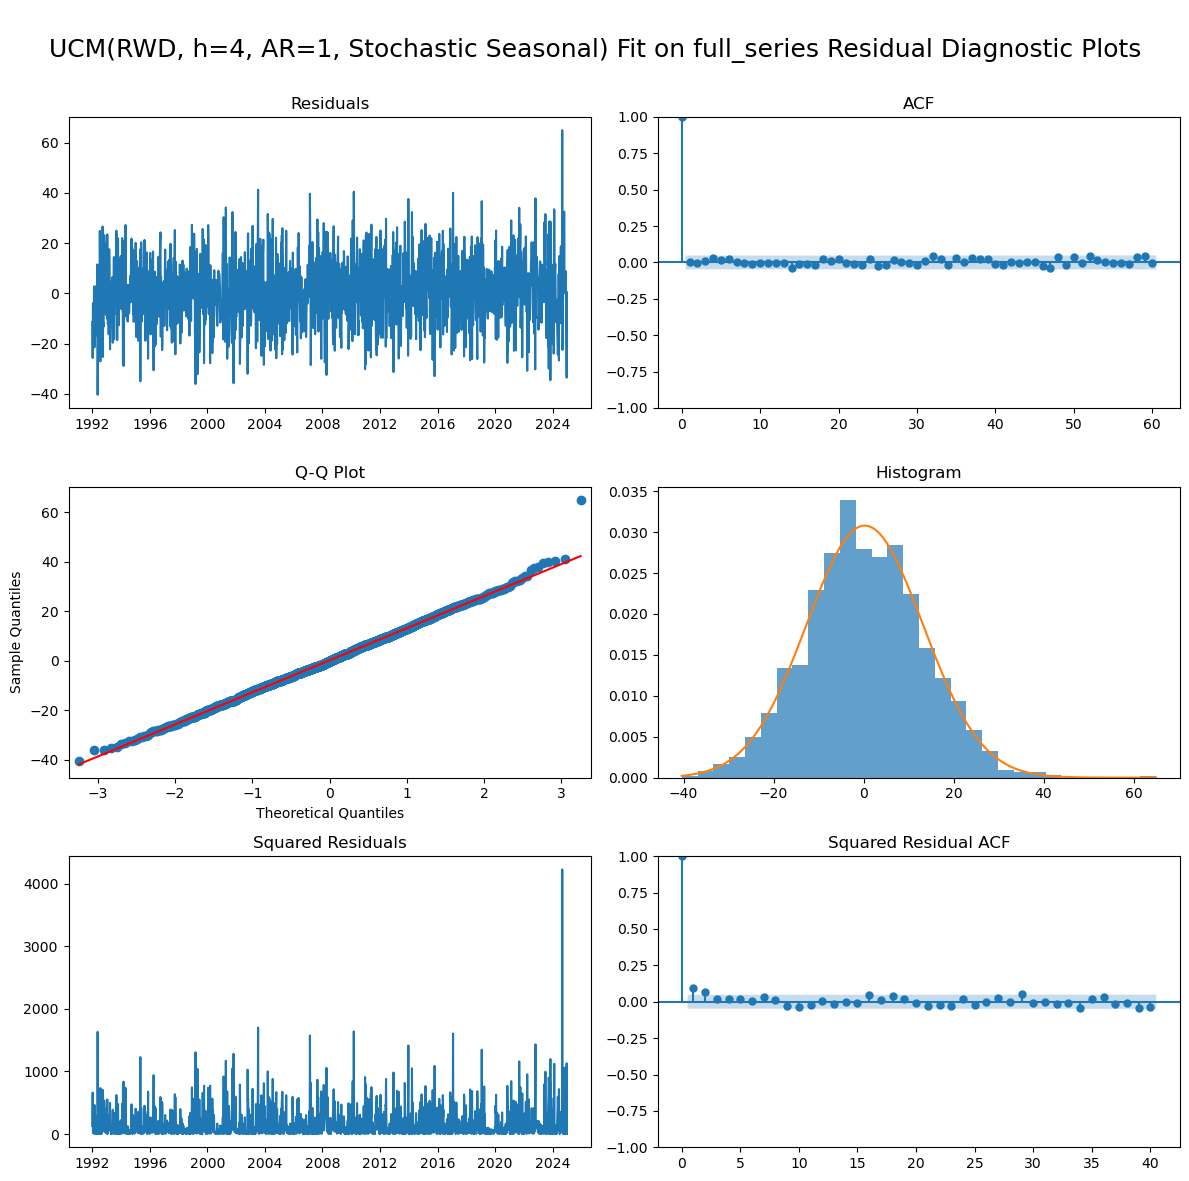

{'mean': np.float64(0.24952885948255046),
 'std': np.float64(12.950737693839955),
 'skew': np.float64(0.11825796953194968),
 'kurtosis': np.float64(0.22163714423170244),
 'ljung_box':       lb_stat  lb_pvalue
 1    0.033640   0.854474
 4    2.222809   0.694856
 13   3.831229   0.992858
 26  12.415947   0.988575
 52  37.311856   0.937821,
 'jb_pvalue': np.float64(0.024707693200712956),
 'adf_pvalue': 0.0,
 'arch_pvalue': np.float64(0.0008521665517187518)}

In [66]:
# residual diagnostics of UCM (random walk with drift, K=4, AR=1, stochastic seasonal) fit on full_series

full_model_res_resid_diag = me.residual_diagnostics(
    full_model_res.resid,
    burnin=52,
    title='UCM(RWD, h=4, AR=1, Stochastic Seasonal) Fit on full_series',
    plot=True,
    return_results=True
)

full_model_res_resid_diag

In [67]:
prior_good_params = fitted_models['UCM'].params

full_model_check_refit = fc.sanity_check_refit(
    full_model_res, 
    full_series, 
    'UCM',
    prior_good_params=prior_good_params
)

full_model_check_refit


Sanity check: UCM refit on 1991-01-06 to 2024-12-29
✓ No issues detected — refit looks consistent with prior years


True

In [68]:
model_fits_full_series = {}

ucm_full_series = UnobservedComponents(full_series, **model_specs['UCM'])
model_fits_full_series['UCM'] = ucm_full_series.fit(
    start_params=fitted_models['UCM'].params,  # warm start from the training data model fit results
    method='lbfgs', 
    maxiter=2000, 
    disp=False)

sarima_full_series = SARIMAX(full_series, **model_specs['SARIMA'])
model_fits_full_series['SARIMA'] = sarima_full_series.fit(
    start_params=fitted_models['SARIMA'].params,  # warm start from the training data model fit results
    method='lbfgs', 
    maxiter=2000, 
    disp=False)

print('fitted models on full data series:')
for name in model_fits_full_series:
    print(f'  {name}: OK')

fitted models on full data series:
  UCM: OK
  SARIMA: OK


## rolling CRPS on full series

In [69]:
# --- UCM model ---
model_label = "UCM_full_series(l=random walk with drift, h=4, ar=1, sfs=[True])"  

clean_label = (
    model_label
    .replace("(", "")
    .replace(")", "")
    .replace("[", "")
    .replace("]", "")
    .replace("=", "")
    .replace("'", "")
    .replace(", ", "_")
    .replace(",", "_")
    .replace(" ", "_")
)

ckpt_path = me.make_checkpoint_path(
    eval_type="rolling_crps",
    model_type="UCM",
    model_label=clean_label
)

ucm_crps_full_series = me.load_or_compute(
    ckpt_path,
    lambda: me.rolling_crps(
        y=full_series,
        model_type='ucm',
        model_params=model_specs['UCM'],
        start_train_size=260,
        horizons=(1,13,26,52),
        step=1, 
        progress=True
    )   
)

Loading checkpoint: checkpoints\rolling_crps\UCM\UCM_full_serieslrandom_walk_with_drift_h4_ar1_sfsTrue.pkl


## calibrate intervals 

In [70]:
ucm_cal_full_series = pc.run_calibration_pipeline(
    'UCM', 
    ucm_crps_full_series,
    common_start_idx=260
)


Calibration summary: UCM
Scale factors:
horizon
1     1.0276
13    1.0362
26    1.0487
52    1.0884
Name: z2, dtype: float64

--- Target Coverage: 50% ---
Final alpha_t:
horizon
1     0.52
13    0.50
26    0.50
52    0.52
Name: alpha_t, dtype: float64
Post-ACI coverage:
horizon
1     0.5010
13    0.5003
26    0.5003
52    0.5010
Name: covered_aci, dtype: float64

--- Target Coverage: 80% ---
Final alpha_t:
horizon
1     0.148
13    0.128
26    0.088
52    0.153
Name: alpha_t, dtype: float64
Post-ACI coverage:
horizon
1     0.7984
13    0.7977
26    0.7963
52    0.7984
Name: covered_aci, dtype: float64

--- Target Coverage: 95% ---
Final alpha_t:
horizon
1     0.012
13    0.032
26    0.023
52    0.018
Name: alpha_t, dtype: float64
Post-ACI coverage:
horizon
1     0.9487
13    0.9494
26    0.9487
52    0.9474
Name: covered_aci, dtype: float64


## forecast

In [71]:
# NOTE: this is the "operational" forecast, which is a forecast from the model fit and calibrated on the full series

# set the number of time steps to forecast (n_forecast; 1-52) and calibration interval (target_coverage; 0.50, 0.80, or 0.95)
# in the "forecast execution arguments" section above.

# calibration of the full_series
cal = ucm_cal_full_series 
final_alpha = cal['calibrations'][target_coverage]['final_alpha']

# generate raw forecast
fc_full = full_model_res.get_forecast(steps=n_forecast)
mu_full = fc_full.predicted_mean
sigma_full = fc_full.se_mean

# apply variance scaling + adaptive conformal inference (ACI)
sf_horizons = sorted(cal['scale_factors'].index.tolist())
alpha_horizons = sorted(final_alpha.index.tolist())

last_date = full_series.index[-1]

rows = []
for i in range(n_forecast):
    h = i + 1
    h_sf = max([x for x in sf_horizons if x <= h], default=sf_horizons[0])
    h_alpha = max([x for x in alpha_horizons if x <= h], default=alpha_horizons[0])

    sigma_cal = sigma_full.iloc[i] * cal['scale_factors'].loc[h_sf]
    z_t = stats.norm.ppf(1 - final_alpha.loc[h_alpha] / 2)

    forecast_date = last_date + pd.Timedelta(weeks=h)

    rows.append({
        'horizon': h,
        'date': forecast_date,
        'y_pred': mu_full.iloc[i],
        'sigma': sigma_full.iloc[i],
        'sigma_calibrated': sigma_cal,
        'lower': mu_full.iloc[i] - z_t * sigma_cal,
        'upper': mu_full.iloc[i] + z_t * sigma_cal
    })

operational_forecast_df = pd.DataFrame(rows)
print('Operational forecast from model fit and calibration on the full series')
print(f"- Forecast range: {operational_forecast_df['date'].min().date()} " 
      f"to {operational_forecast_df['date'].max().date()}\n")
print(operational_forecast_df.head())


Operational forecast from model fit and calibration on the full series
- Forecast range: 2025-01-05 to 2025-12-28

   horizon       date       y_pred      sigma  sigma_calibrated        lower  \
0        1 2025-01-05  1954.379621  12.909171         13.266069  1921.053341   
1        2 2025-01-12  1954.430102  13.084840         13.446595  1920.650314   
2        3 2025-01-19  1954.391574  13.133687         13.496792  1920.485685   
3        4 2025-01-26  1954.357682  13.171748         13.535905  1920.353534   
4        5 2025-02-02  1954.272521  13.205090         13.570170  1920.182295   

         upper  
0  1987.705902  
1  1988.209890  
2  1988.297463  
3  1988.361830  
4  1988.362746  


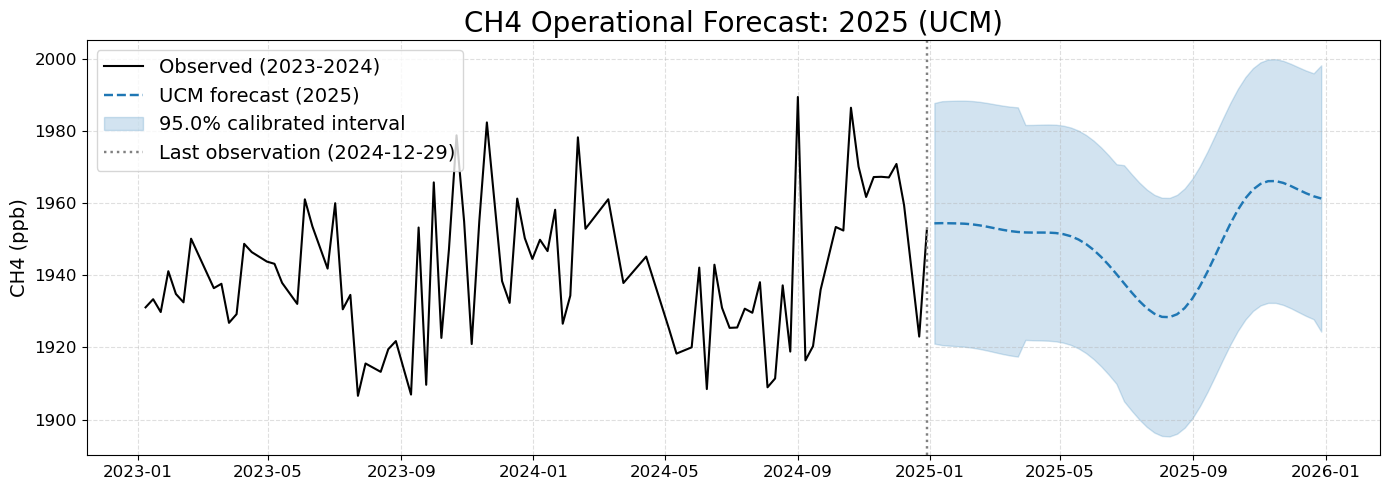

In [72]:
# set model type
model = 'UCM'

# Recent observed history for context
recent_tail = full_series.iloc[-104:]  # last three years
start_year = recent_tail.index[0].year
end_year = recent_tail.index[-1].year
forecast_year = (recent_tail.index[-1] + pd.DateOffset(weeks=4)).year

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(recent_tail.index, recent_tail.values, color='black',
        linewidth=1.5, label=f'Observed ({start_year}-{end_year})')

# Forecast
line, = ax.plot(operational_forecast_df['date'], operational_forecast_df['y_pred'],
                linewidth=1.75, linestyle='--', label=f'{model} forecast ({forecast_year})')
ax.fill_between(operational_forecast_df['date'], operational_forecast_df['lower'],
                operational_forecast_df['upper'], color=line.get_color(), alpha=0.2,
                label=f'{target_coverage*100}% calibrated interval')

ax.axvline(full_series.index[-1], color='gray', linestyle=':', linewidth=1.75,
           label=f'Last observation ({recent_tail.index[-1].strftime('%Y-%m-%d')})')

ax.set_title(f'CH4 Operational Forecast: {forecast_year} ({model})', fontsize=20)
ax.set_ylabel('CH4 (ppb)', fontsize=14)

ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=14, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Note about the intervals shape**

The shape of the intervals over time is based on the sigma that the state-space UCM produces. The interval width is due to three sources of uncertainty in this model: level/drift, the irregular term, and the four seasonal harmonics.  
- The level/drift uncertainty, sigma2.level, is about the long-run trajectory of the series.  Generally, uncertainty compounds with forecast horizon and will produce a classic fan shape.  
- The second source of uncertainty is the irregular term (sigma2.ar, ar.L1).  This term represents short-term, mean-reverting noise around the trend.  This model fit has ar.L1 = 0.09, which is a very weak persistence.  The noise's contribution to forecast variance reaches its full value almost immediately, by h=2.
- The third source of uncertainty comes from the four seasonal harmonics.  sigma2.freq_seasonal_52.18(4) value of 0.0018 is very small in magnitude compared with the other sources of uncertainty.  
- For this model fit, sigma2.ar (154) dominates both sigma2.level (0.65) and sigma2.freq_seasonal_52.18(4) (0.0018) in magnitude.  The large, fast-saturating AR noise sets the overall width immediately, while the small, compounding level/drift uncertainty doesn't add much on top of the irregular uncertainty.  Therefore a more "tube"-like interval is produced.  

In [73]:
# print the operational forecast values at 1, 13, 26, and 52 weeks ahead

operational_forecast_values = operational_forecast_df[operational_forecast_df['horizon'].isin([1, 13, 26, 52])].copy()

# operational_forecast_values['label'] = operational_forecast_values['horizon'].map({
#     1: '1 week ahead',
#     13: '~1 quarter ahead',
#     26: '~6 months ahead',
#     52: '~1 year ahead'
# })

print('Operational Forecast Values at Specific Horizons (Weeks Ahead):\n')
columns_to_print = ['horizon', 'date', 'y_pred', 'lower', 'upper']
print(operational_forecast_values[columns_to_print].round(2).to_string(index=False))

Operational Forecast Values at Specific Horizons (Weeks Ahead):

 horizon       date  y_pred   lower   upper
       1 2025-01-05 1954.38 1921.05 1987.71
      13 2025-03-30 1951.85 1922.08 1981.62
      26 2025-06-29 1937.78 1905.08 1970.48
      52 2025-12-28 1961.26 1924.38 1998.14


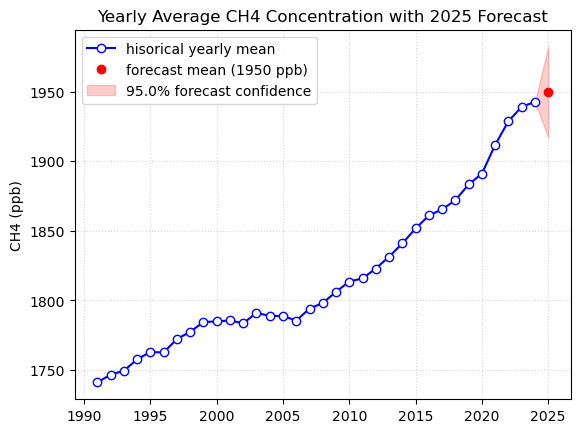

In [74]:
# print the yearly average CH4 concentration from 1991 - 2025

yearly_mean = full_series.groupby(full_series.index.year).mean()
forecast_mean = operational_forecast_df['y_pred'].mean()
forecast_year = operational_forecast_df['date'].dt.year.iloc[5]

# Calculate average lower and upper bounds for forecast year
fc_lower_mean = operational_forecast_df['lower'].mean()
fc_upper_mean = operational_forecast_df['upper'].mean()

plt.plot(yearly_mean.index, yearly_mean.values, 'bo-', markerfacecolor='w', label='hisorical yearly mean')
plt.plot(forecast_year, forecast_mean, 'ro', label=f'forecast mean ({forecast_mean:.0f} ppb)')

# add the mean 95% confidence interval
plt.fill_between([yearly_mean.index[-1], forecast_year], 
                 [yearly_mean.values[-1], fc_lower_mean],
                 [yearly_mean.values[-1], fc_upper_mean],
                 color='red', alpha=0.2, label=f'{target_coverage*100}% forecast confidence'
                )
plt.ylabel('CH4 (ppb)')
plt.title(f'Yearly Average CH4 Concentration with {forecast_year} Forecast')

plt.legend()
plt.grid(linestyle=':', alpha=0.5)

plt.show()

## comparison: forecast vs operational forecast

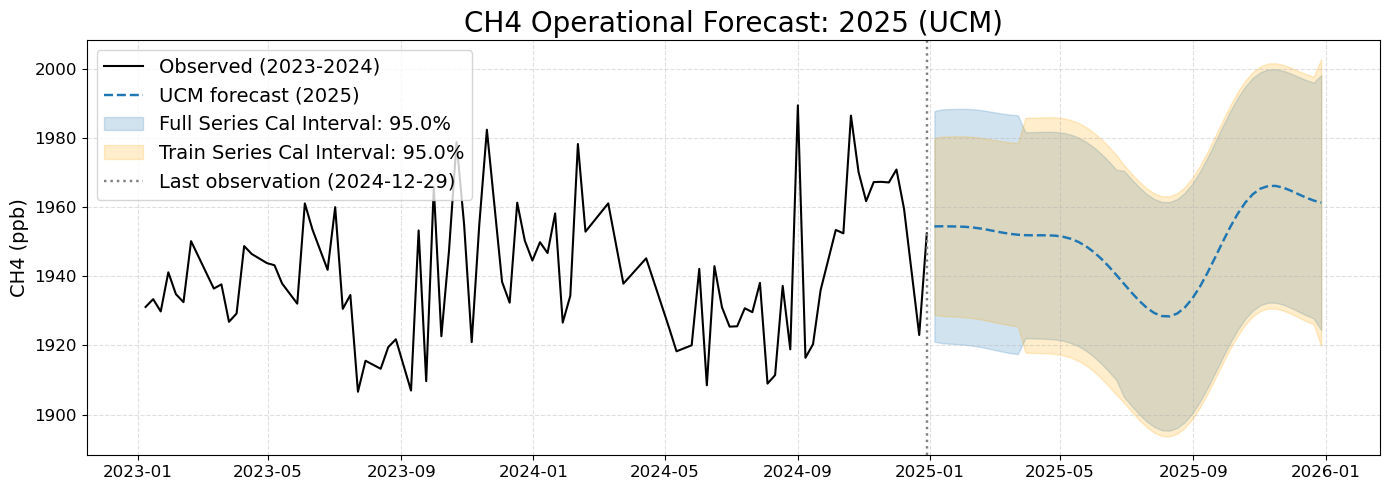

In [75]:
# set model type
model = 'UCM'

# Recent observed history for context
recent_tail = full_series.iloc[-104:]  # last two years
start_year = recent_tail.index[0].year
end_year = recent_tail.index[-1].year
forecast_year = (recent_tail.index[-1] + pd.DateOffset(weeks=4)).year

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(recent_tail.index, recent_tail.values, color='black',
        linewidth=1.5, label=f'Observed ({start_year}-{end_year})')

# Forecast
line, = ax.plot(operational_forecast_df['date'], operational_forecast_df['y_pred'],
                linewidth=1.75, linestyle='--', label=f'{model} forecast ({forecast_year})')
ax.fill_between(operational_forecast_df['date'], operational_forecast_df['lower'],
                operational_forecast_df['upper'], color=line.get_color(), alpha=0.2,
                label=f'Full Series Cal Interval: {target_coverage*100}%')

# forecast intervals calibrated on train data only
ax.fill_between(forecast_df['date'], forecast_df['lower'],
                forecast_df['upper'], color='orange', alpha=0.2,
                label=f'Train Series Cal Interval: {target_coverage*100}%')

ax.axvline(full_series.index[-1], color='gray', linestyle=':', linewidth=1.75,
           label=f'Last observation ({recent_tail.index[-1].strftime('%Y-%m-%d')})')

ax.set_title(f'CH4 Operational Forecast: {forecast_year} ({model})', fontsize=20)
ax.set_ylabel('CH4 (ppb)', fontsize=14)

ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=14, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Operational Forecast

- This version of the operational forecast calls functions from the .py files in the SRC folder of the GitHub project repository.
- It is redundant, in function, with the operational forecast code section above, which keeps the operational forecasting code within the notebook.
- The major differences for this final operational forecast code is that it:
  - streamlines code and removes code redundancy for forecasting with more than one model.
  - the forecasting code is generalizable to other models and future applications to other greenhouse gases
  - uses for loops to include both top models in the final operational forecast instead of just one of them.  


UCM Results Summary Table
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
sigma2.level                      0.6755      0.195      3.467      0.001       0.294       1.057
sigma2.freq_seasonal_52.18(4)     0.0020      0.002      1.334      0.182      -0.001       0.005
sigma2.ar                       154.0521      5.122     30.076      0.000     144.013     164.091
ar.L1                             0.0904      0.024      3.802      0.000       0.044       0.137

=== Residual Diagnostics: UCM - full series ===
Mean    : 0.24197
Std     : 12.95107
Skew    : 0.117
Kurtosis: 0.223

Jarque-Bera p-value: 0.0250

Ljung-Box p-values:
  lag 1: p = 0.8736
  lag 4: p = 0.7162
  lag 13: p = 0.9941
  lag 26: p = 0.9886
  lag 52: p = 0.9416

Engle's ARCH test (nlags=52) p-value: 8.2533e-04

ADF p-value: 0.0000


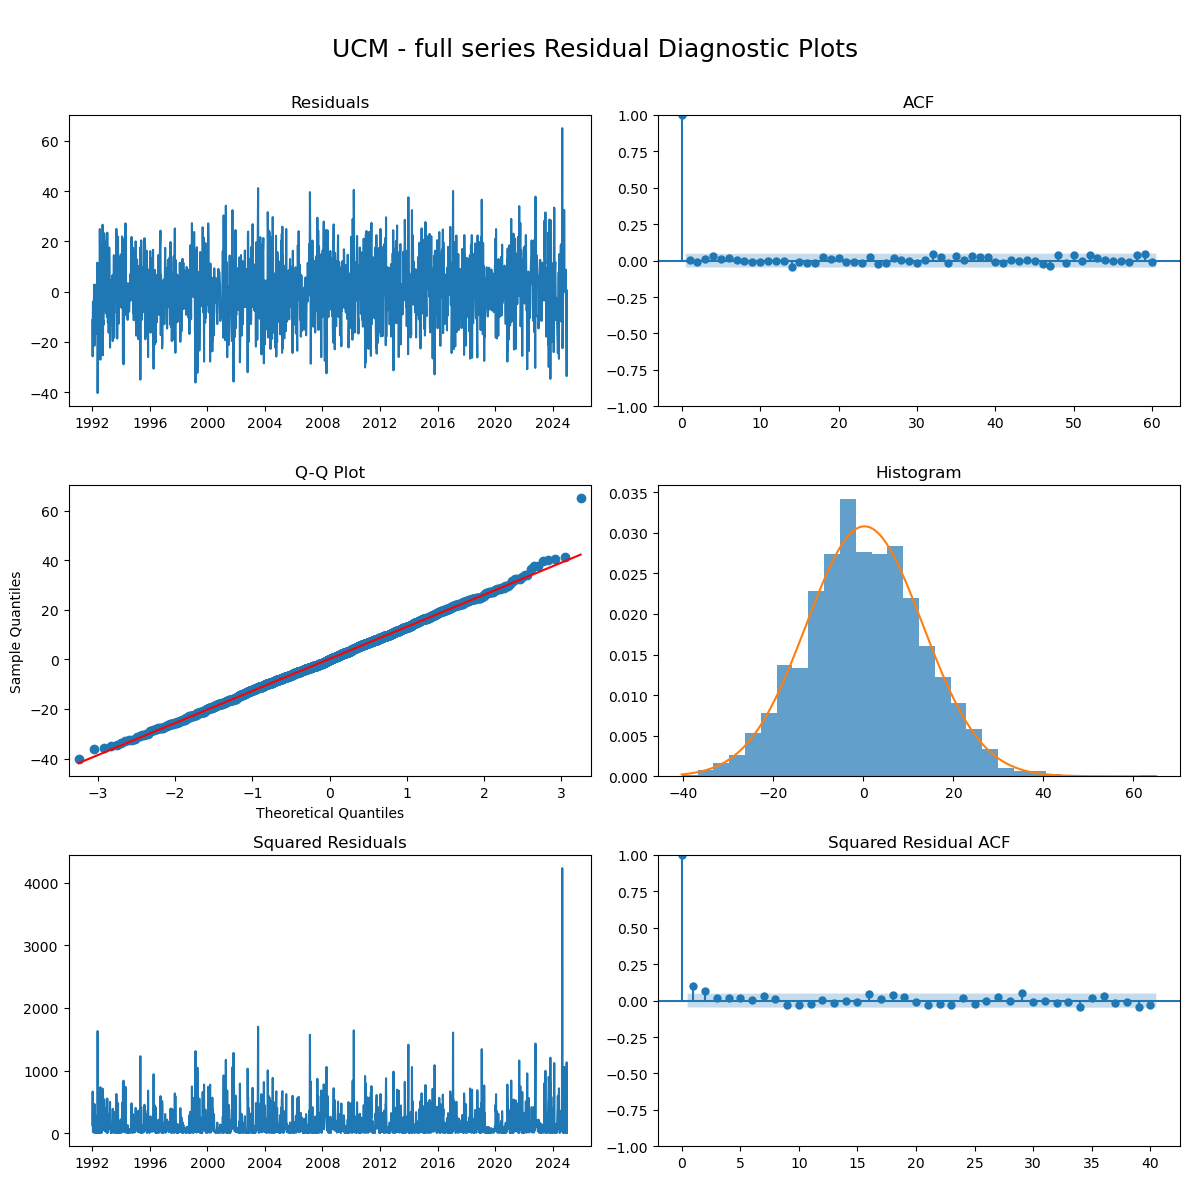


Sanity check: UCM refit on 1991-01-06 to 2024-12-29
✓ No issues detected — refit looks consistent with prior years

SARIMA Results Summary Table
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0016      0.001      1.303      0.193      -0.001       0.004
ar.L1          0.1535      0.023      6.680      0.000       0.108       0.199
ma.L1         -0.9453      0.008   -114.511      0.000      -0.961      -0.929
ar.S.L52       0.9852      0.005    181.056      0.000       0.974       0.996
ma.S.L52      -0.8807      0.019    -46.058      0.000      -0.918      -0.843
sigma2       175.7003      5.973     29.418      0.000     163.994     187.406

=== Residual Diagnostics: SARIMA - full series ===
Mean    : 0.13992
Std     : 13.38780
Skew    : 0.115
Kurtosis: 0.011

Jarque-Bera p-value: 0.1525

Ljung-Box p-values:
  lag 1: p = 0.8834
  lag 4: p = 0.0685
  lag 13: p

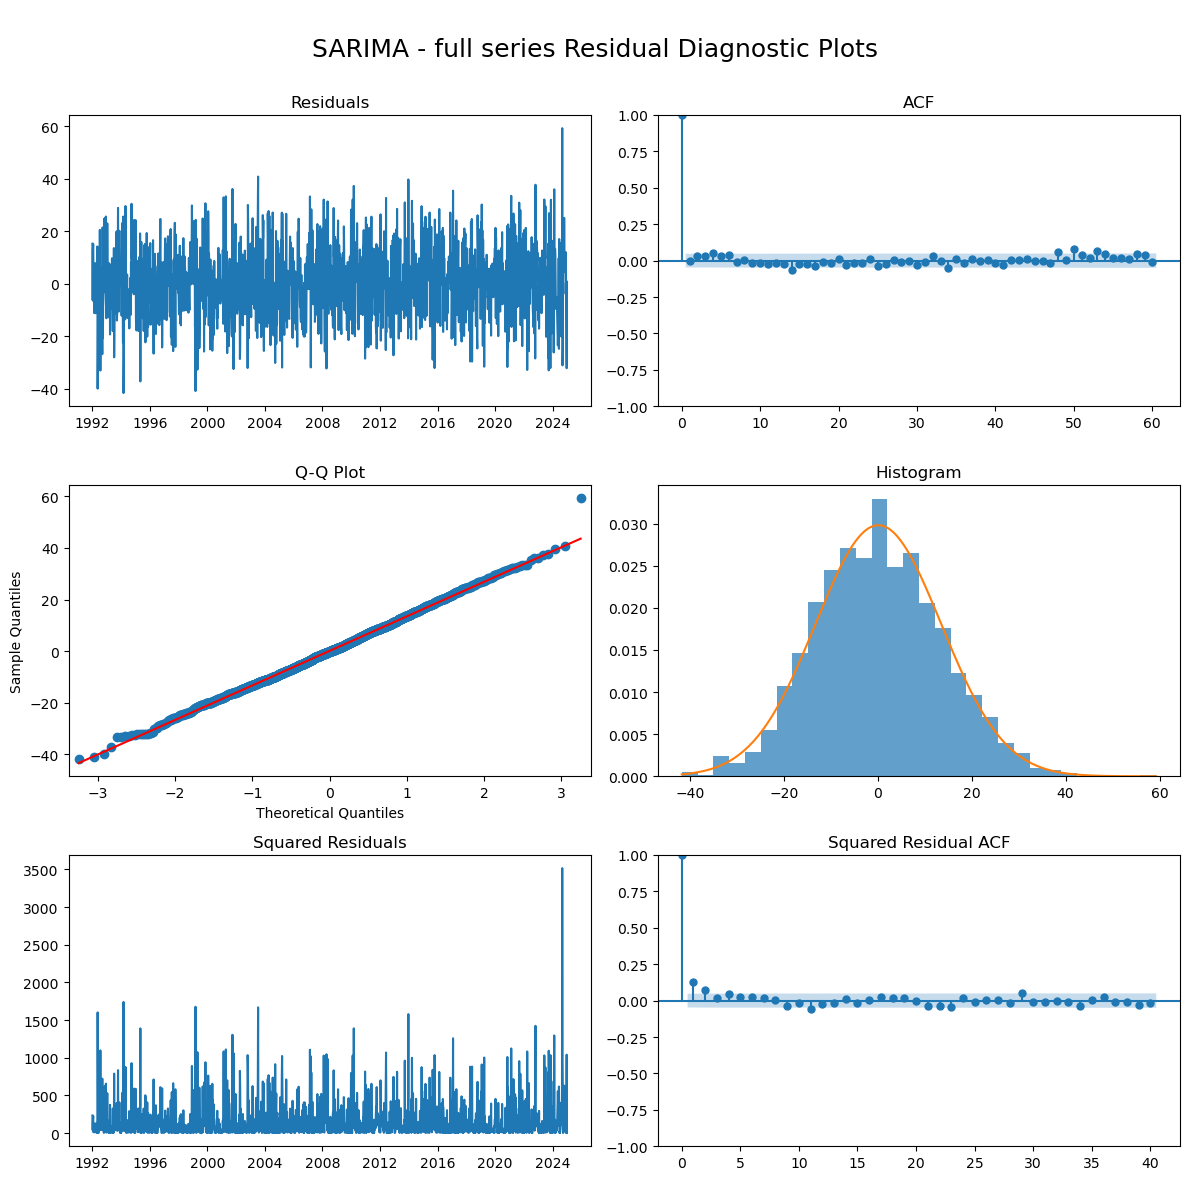


Sanity check: SARIMA refit on 1991-01-06 to 2024-12-29
✓ No issues detected — refit looks consistent with prior years
Loading checkpoint: checkpoints\rolling_crps_full\ucm\UCM.pkl

Calibration summary: UCM
Scale factors:
horizon
1     1.0276
13    1.0362
26    1.0487
52    1.0884
Name: z2, dtype: float64

--- Target Coverage: 50% ---
Final alpha_t:
horizon
1     0.52
13    0.50
26    0.50
52    0.52
Name: alpha_t, dtype: float64
Post-ACI coverage:
horizon
1     0.5010
13    0.5003
26    0.5003
52    0.5010
Name: covered_aci, dtype: float64

--- Target Coverage: 80% ---
Final alpha_t:
horizon
1     0.148
13    0.128
26    0.088
52    0.153
Name: alpha_t, dtype: float64
Post-ACI coverage:
horizon
1     0.7984
13    0.7977
26    0.7963
52    0.7984
Name: covered_aci, dtype: float64

--- Target Coverage: 95% ---
Final alpha_t:
horizon
1     0.012
13    0.032
26    0.023
52    0.018
Name: alpha_t, dtype: float64
Post-ACI coverage:
horizon
1     0.9487
13    0.9494
26    0.9487
52    0.9474

In [79]:
# fit, diagnose, and sanity check
model_fits_full = {}
diagnostics_full = {}
for name, cfg in [
    ('UCM', 
     dict(spec=model_specs['UCM'], 
          cls=UnobservedComponents, 
          prior=fitted_models['UCM'].params)),
    ('SARIMA', 
     dict(spec=model_specs['SARIMA'], 
          cls=SARIMAX, 
          prior=fitted_models['SARIMA'].params))
]:
    result, diag, ok = fc.fit_and_check_full_series(
        name, 
        cfg['spec'], 
        cfg['cls'], 
        cfg['prior'], 
        full_series
    )
    model_fits_full[name] = result
    diagnostics_full[name] = diag
    
# rolling CRPS + calibration pipeline
calibration_full = {}
for name, model_type, model_params, start_size in [
    ('UCM', 'ucm', model_specs['UCM'], 260),
    ('SARIMA', 'sarima', model_specs['SARIMA'], 260)
]:
    ckpt = me.make_checkpoint_path('rolling_crps_full', model_type, name)
    crps_df = me.load_or_compute(
        ckpt,
        lambda mt=model_type, mp=model_params, ss=start_size: me.rolling_crps(
            y=full_series,
            model_type=mt,
            model_params=mp,
            start_train_size=ss,
            horizons=(1,13,26,52),
            step=1,
            progress=True
        )
    )
    calibration_full[name] = pc.run_calibration_pipeline(
        name,
        crps_df,
        common_start_idx=start_size
    )
        
# store results in a dictionary
operational_forecast_dict = {
    name: fc.operational_forecast(
        name=name, 
        model_fits_dict=model_fits_full, 
        calibration_dict=calibration_full,
        full_series=full_series
    ) 
    for name in ['UCM', 'SARIMA']
}

In [84]:
print(operational_forecast_dict.keys())
print(operational_forecast_dict.values())

dict_keys(['UCM', 'SARIMA'])
dict_values([   model  horizon       date       y_pred  sigma_calibrated        lower  \
0    UCM        1 2025-01-05  1954.351168         13.270012  1921.014984   
1    UCM        2 2025-01-12  1954.428280         13.461690  1921.233000   
2    UCM        3 2025-01-19  1954.430803         13.523259  1921.644895   
3    UCM        4 2025-01-26  1954.439513         13.573567  1922.043375   
4    UCM        5 2025-02-02  1954.389813         13.618765  1922.356820   
5    UCM        6 2025-02-09  1954.229918         13.659404  1922.538197   
6    UCM        7 2025-02-16  1953.942365         13.696206  1922.573014   
7    UCM        8 2025-02-23  1953.545385         13.730274  1922.480670   
8    UCM        9 2025-03-02  1953.085450         13.762857  1922.307826   
9    UCM       10 2025-03-09  1952.624091         13.795152  1922.115867   
10   UCM       11 2025-03-16  1952.222160         13.828154  1921.965603   
11   UCM       12 2025-03-23  1951.924890     

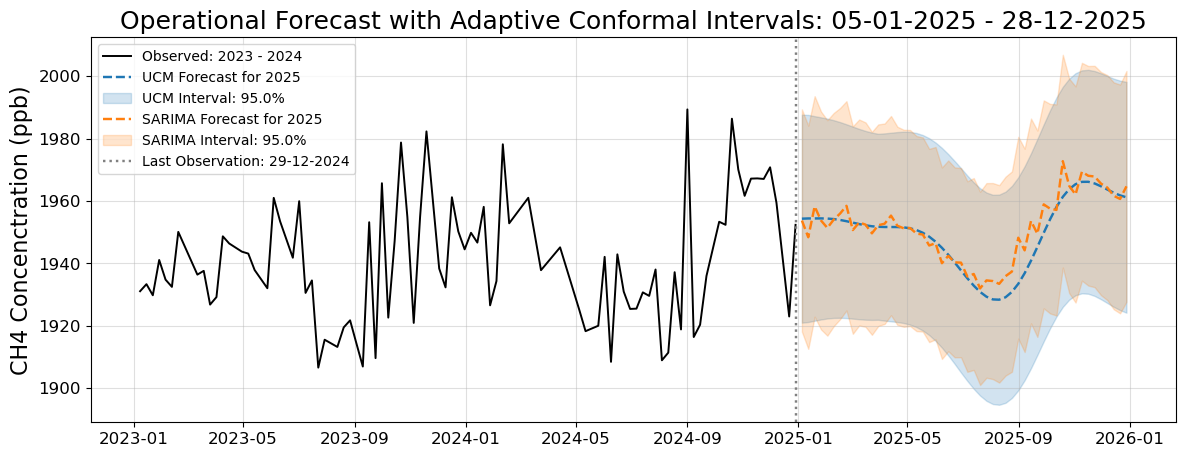

In [108]:
models = ['UCM', 'SARIMA']

recent_tail = full_series.iloc[-104:]
start_year = recent_tail.index[0].year
end_year = recent_tail.index[-1].year
forecast_year = (recent_tail.index[-1] + pd.DateOffset(weeks=4)).year
# get forecast start and end dates from one of the models
first_df = next(iter(operational_forecast_dict.values()))
fc_start = first_df['date'].iloc[0].strftime('%d-%m-%Y')
fc_end = first_df['date'].iloc[-1].strftime('%d-%m-%Y')




# forecast_start = operational_forecast_dict['UCM']['date'].iloc[0].strftime('%d-%m-%Y')
# forecast_end = operational_forecast_dict['UCM']['date'].iloc[-1].strftime('%d-%m-%Y')

# plot
fig, ax = plt.subplots(figsize=(14,5))

# plot the observed data
ax.plot(recent_tail.index, recent_tail.values, color='black', linewidth=1.4, label=f'Observed: {start_year} - {end_year}')

# add the forecasts
for name, df in operational_forecast_dict.items():
    line, = ax.plot(df['date'], df['y_pred'], linewidth=1.75, linestyle='--', label=f'{name} Forecast for {forecast_year}')

    ax.fill_between(
        df['date'],
        df['lower'],
        df['upper'],
        color=line.get_color(),
        alpha=0.2,
        label=f'{name} Interval: {target_coverage * 100}%'
    )

ax.axvline(recent_tail.index[-1], color='gray', linewidth=1.75, linestyle=':', label=f'Last Observation: {recent_tail.index[-1].strftime('%d-%m-%Y')}')

ax.set_title(f'Operational Forecast with Adaptive Conformal Intervals: {fc_start} - {fc_end}', fontsize=18)
ax.set_ylabel('CH4 Concenctration (ppb)', fontsize=16)
ax.legend()
ax.tick_params(axis='both', labelsize=12)
ax.grid(alpha=0.4)

plt.show()
    

# Save the forecast values

In [72]:
output_dir = Path('../results')
operational_forecast_df.to_csv(output_dir / 'CH4_forecast_2025_UCM.csv', index=False)
operational_forecast_df.to_pickle(output_dir / 'CH4_forecast_2025_UCM.pkl')

# Notes about this notebook

This notebook is being saved to maintain some code that will not be included in the final version, including:
- forecast with interval calibration from train data only
- operational forecasts from specific code localized to this notebook and operational forecasts from generalizable code stored in SRC folder .py files.

The final forecasting notebook will edit out all but the final operational forecast and be labeled as 5_ch4_forecasting.py.  

# Forecast summary

A closing summary/caveats cell — you mentioned this plan much earlier in the project; worth confirming it's present: model selection rationale (pointing back to the modeling notebook), the known SARIMAX/UCMX vulnerability to a training cutoff landing mid-surge, and an explicit statement that the 2025 forecast assumes no new regime shift occurs.

*A short caveats paragraph, since you now have a forward forecast that nobody can fact-check yet:*

This forecast assumes the current growth regime (post-2020 acceleration, as captured in training through 2024) continues into 2025 without a new structural breakpoint. Calibration (variance scaling, ACI alpha) is inherited from the 1991–2022 training-period rolling evaluation rather than re-estimated on the refit model, under the assumption that the model's characteristic error structure is stable under the addition of two more years of data. The 2024 test period demonstrated this model class's known vulnerability to anomalous seasonal departures from trend (see Section [X]); the 95% interval reported here should be read as conditional on no comparable anomaly occurring in 2025.

**regarding the 2024 trough suppression characterized in 3_ch4_preprocessing_eda**

Note: Wang et al. (2026) explains the annual pace of CH4 increase, not
the shape of the seasonal cycle. A separate, localized finding from
this project's EDA (see 3_ch4_preprocessing_eda, "2024 seasonal
anomaly") shows 2024 ran 1.5–2.9 SD below its typical seasonal shape
from mid-April through early June — a moderate suppression in the
spring trough. No mechanistic link between the growth-rate deceleration
and this seasonal-shape finding is established here.



**Regarding choice of publishing venue**

*From Claude*

On Medium as a Venue

Reasonable choice, and worth saying plainly: this project is genuinely strong methods-and-process writing — the diagnostic rigor (catching the lag-7 artifact, chasing down the ISO-week boundary bug, the convergence-failure investigation, the honest DM-test power analysis) is exactly the kind of narrative that reads well as an applied case study, even though it wouldn't clear a journal's novelty bar. A Medium post framed around "what a full, honest applied forecasting pipeline actually looks like — including the mistakes" would likely be more useful and more differentiated content than a dry results-only write-up, given how much genuine debugging and self-correction is documented in this conversation.